In [1]:
import os

os.chdir(
    r"C:\Users\nandi\OneDrive\Desktop\mutual_fund_analysis"
)

print(os.getcwd())

C:\Users\nandi\OneDrive\Desktop\mutual_fund_analysis


In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import os

os.makedirs("charts", exist_ok=True)
os.makedirs("reports", exist_ok=True)

In [32]:
nav = pd.read_csv(
    "data/processed/nav_history_clean.csv"
)

perf = pd.read_csv(
    "data/processed/scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "data/processed/10_benchmark_indices_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print(nav.shape)
print(perf.shape)
print(benchmark.shape)

(46000, 3)
(40, 19)
(8050, 3)


In [33]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")
    ["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


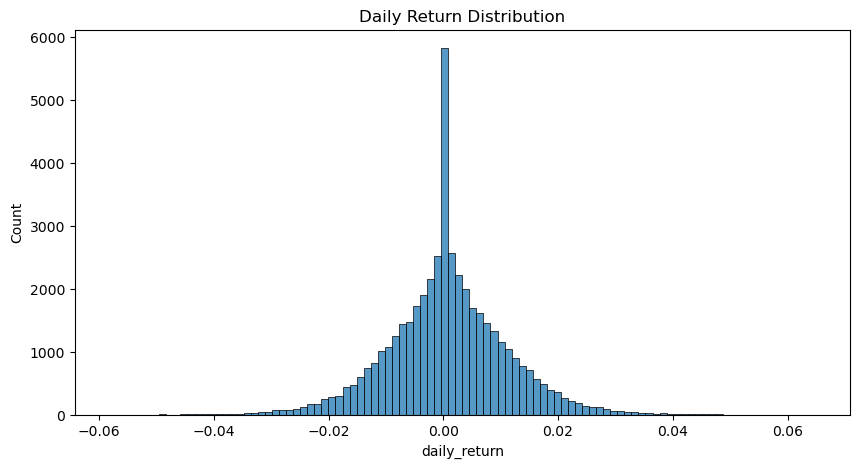

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [35]:
cagr_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    start_nav = temp["nav"].iloc[0]

    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        **
        (1 / years)
    ) - 1

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [36]:
RF = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    sharpe = (
        (
            returns.mean() * 252
            -
            RF
        )
        /
        (
            returns.std()
            *
            np.sqrt(252)
        )
    )

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe"
    ]
)

sharpe_df.head()

,amfi_code,sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [37]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (
            returns.mean()*252
            -
            RF
        )
        /
        (
            downside.std()
            *
            np.sqrt(252)
        )
    )

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino"
    ]
)

sortino_df.head()

,amfi_code,sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [38]:
alpha_beta_df = perf[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

alpha_beta_df.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [39]:
dd_df = perf[
    [
        "amfi_code",
        "max_drawdown_pct"
    ]
].copy()

dd_df.columns = [
    "amfi_code",
    "max_drawdown"
]

dd_df.head()

,amfi_code,max_drawdown
0,119551,-21.70
1,119552,-24.43
2,119598,-13.35
3,119599,-24.78
4,119120,-2.30


In [40]:
score = perf[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown_pct"
    ]
].copy()

score["return_rank"] = (
    score["return_3yr_pct"]
    .rank(pct=True)
)

score["sharpe_rank"] = (
    score["sharpe_ratio"]
    .rank(pct=True)
)

score["alpha_rank"] = (
    score["alpha"]
    .rank(pct=True)
)

score["expense_rank"] = (
    score["expense_ratio_pct"]
    .rank(
        ascending=False,
        pct=True
    )
)

score["drawdown_rank"] = (
    score["max_drawdown_pct"]
    .rank(
        ascending=False,
        pct=True
    )
)

score["fund_score"] = (
    score["return_rank"] * 30
    +
    score["sharpe_rank"] * 25
    +
    score["alpha_rank"] * 20
    +
    score["expense_rank"] * 15
    +
    score["drawdown_rank"] * 10
)

score = score.sort_values(
    "fund_score",
    ascending=False
)

score.head()

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,1.13,0.72,-24.78,0.975,0.5375,0.4625,0.8875,0.750,72.750
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,0.98,1.85,1.45,-19.50,0.750,0.7250,0.9375,0.4750,0.500,71.500
21,120842,Kotak Emerging Equity Fund - Regular - Growth,18.23,0.96,1.91,1.56,-21.92,0.850,0.6500,0.9750,0.2000,0.625,70.500
29,101207,ABSL Small Cap Fund - Regular - Growth,22.38,0.90,1.84,1.53,-23.61,0.950,0.4125,0.9000,0.3125,0.675,68.250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.23,1.43,-13.35,1.000,0.5750,0.5250,0.5000,0.200,64.375


In [41]:
score.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

print(
    "Fund Scorecard Saved"
)

Fund Scorecard Saved


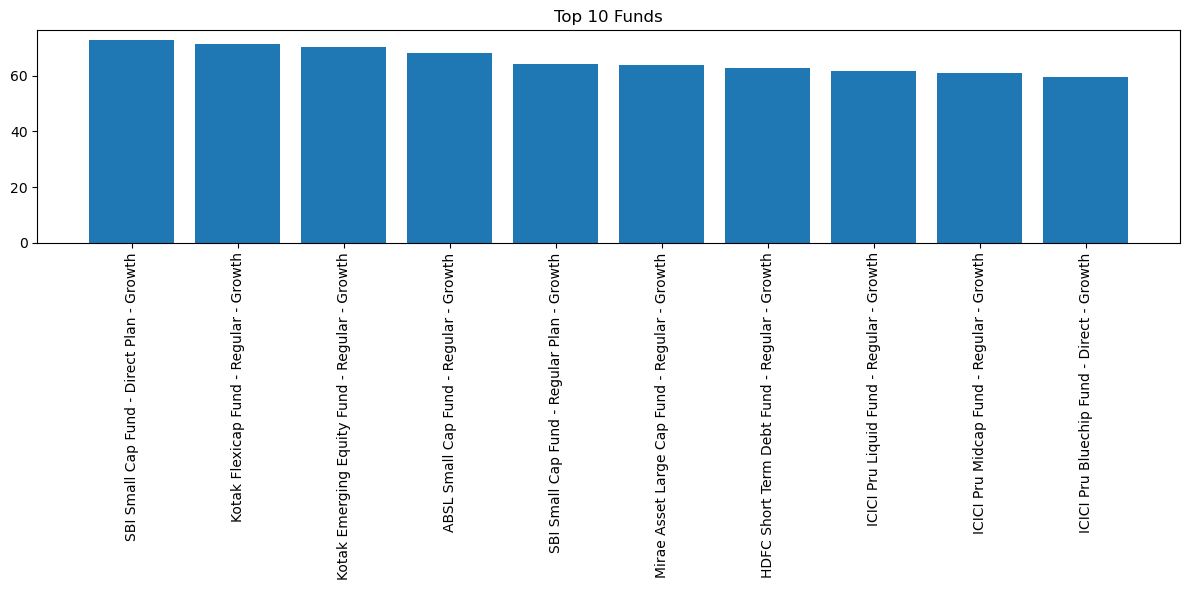

In [43]:
top10 = score.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["fund_score"]
)

plt.xticks(rotation=90)

plt.title(
    "Top 10 Funds"
)

plt.tight_layout()

plt.savefig(
    "charts/top10_funds.png"
)

plt.show()

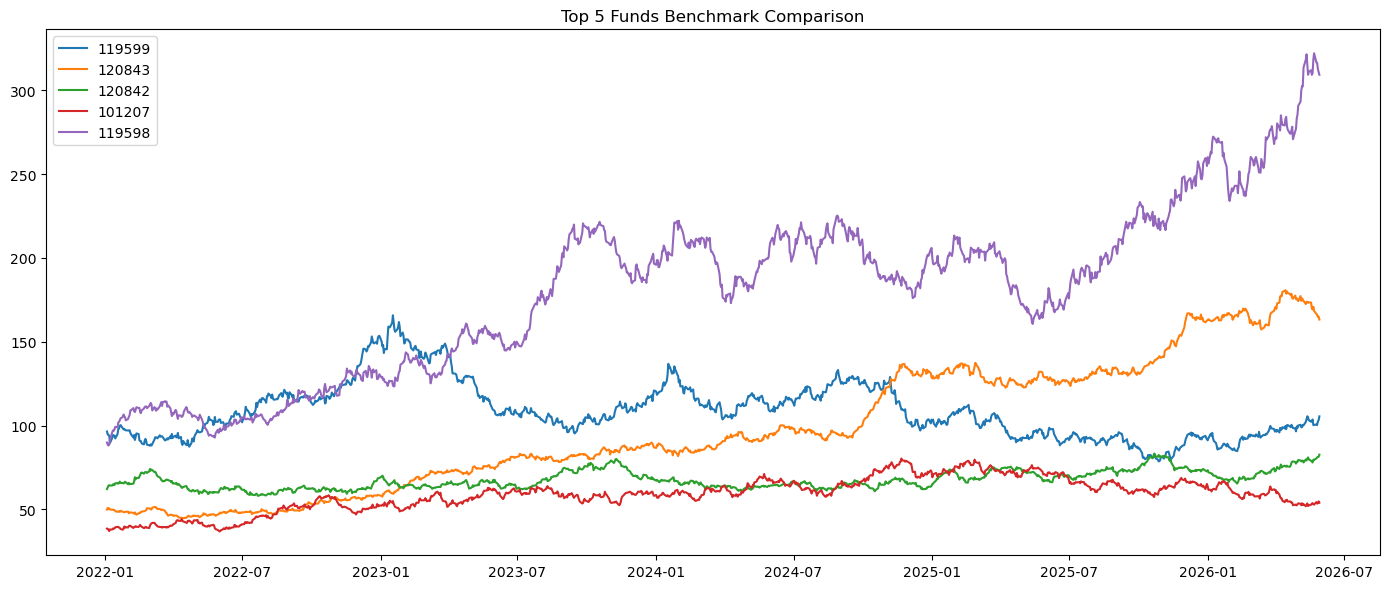

In [44]:
top5_codes = (
    score["amfi_code"]
    .head(5)
)

plt.figure(figsize=(14,6))

for code in top5_codes:

    temp = nav[
        nav["amfi_code"] == code
    ]

    if len(temp) > 0:

        plt.plot(
            temp["date"],
            temp["nav"],
            label=str(code)
        )

plt.legend()

plt.title(
    "Top 5 Funds Benchmark Comparison"
)

plt.tight_layout()

plt.savefig(
    "charts/benchmark_comparison.png"
)

plt.show()

In [45]:
print("Reports:")

print(
    os.listdir("reports")
)

print("\nCharts:")

print(
    os.listdir("charts")
)

Reports:
['alpha_beta.csv', 'fund_scorecard.csv']

Charts:
['benchmark_comparison.png', 'top10_funds.png']
